In [1]:
import random
import pandas as pd

# Map product names to identifiers
product_id_mapping = {'Product 1': 0, 'Product 2': 1}

def generate_events_fixed(quantity, interval, time_period, product_id, event_type):
    """Generate events at fixed intervals with a fixed quantity over a specified time period."""
    num_events = time_period // interval
    times = [i * interval for i in range(num_events)]
    quantities = [quantity] * num_events
    return pd.DataFrame({'Time': times, 'Quantity': quantities, 'Product': product_id, 'Type': event_type})

def generate_events_random(num_events, time_period, max_quantity, product_id, event_type):
    """Generate random events over a specified time period."""
    times = sorted([random.randint(0, time_period) for _ in range(num_events)])
    quantities = [random.randint(1, max_quantity) for _ in range(num_events)]
    return pd.DataFrame({'Time': times, 'Quantity': quantities, 'Product': product_id, 'Type': event_type})

def simulate_events(time_period, product_settings):
    arrivals = []
    demands = []
    for config_name, settings in product_settings.items():
        # Extract the product name (excluding the event type) and map it to its numeric identifier
        product_name = ' '.join(config_name.split()[:-1])
        product_id = product_id_mapping[product_name]
        
        # Generate either fixed or random events for each product
        if settings['interval_type'] == 'fixed':
            df = generate_events_fixed(settings['quantity'], settings['interval'], time_period, product_id, settings['event_type'])
        else:  # Random generation
            num_events = random.randint(10, 20)
            df = generate_events_random(num_events, time_period, settings['max_quantity'], product_id, settings['event_type'])
        
        if settings['event_type'] == 'Arrival':
            arrivals.append(df)
        else:
            demands.append(df)
    
    # Combine all events into separate DataFrames for arrivals and demands, and sort by time
    arrivals_df = pd.concat(arrivals).sort_values('Time').reset_index(drop=True) if arrivals else pd.DataFrame()
    demands_df = pd.concat(demands).sort_values('Time').reset_index(drop=True) if demands else pd.DataFrame()
    return arrivals_df, demands_df

# Set the simulation time period
time_period = 100

# Configuration for each product and event type
product_settings = {
    'Product 1 Arrival': {'event_type': 'Arrival', 'interval_type': 'fixed', 'quantity': 1,'interval': 1},
    'Product 2 Arrival': {'event_type': 'Arrival', 'interval_type': 'fixed', 'quantity': 1, 'interval': 1},
    'Product 1 Demand': {'event_type': 'Demand', 'interval_type': 'fixed', 'quantity': 1, 'interval': 2},
    'Product 2 Demand': {'event_type': 'Demand', 'interval_type': 'fixed', 'quantity': 1, 'interval': 2},
}

# Simulate events for Arrivals and Demands
arrivals_df, demands_df = simulate_events(time_period, product_settings)

# Display the events for Arrivals and Demands
print("Arrivals:")
print(arrivals_df)
print("\nDemands:")
print(demands_df)

#'Product 2 Arrival': {'event_type': 'Arrival', 'interval_type': 'random', 'max_quantity': 5},

Arrivals:
     Time  Quantity  Product     Type
0       0         1        0  Arrival
1       0         1        1  Arrival
2       1         1        0  Arrival
3       1         1        1  Arrival
4       2         1        0  Arrival
..    ...       ...      ...      ...
195    97         1        0  Arrival
196    98         1        1  Arrival
197    98         1        0  Arrival
198    99         1        0  Arrival
199    99         1        1  Arrival

[200 rows x 4 columns]

Demands:
    Time  Quantity  Product    Type
0      0         1        0  Demand
1      0         1        1  Demand
2      2         1        0  Demand
3      2         1        1  Demand
4      4         1        0  Demand
..   ...       ...      ...     ...
95    94         1        0  Demand
96    96         1        1  Demand
97    96         1        0  Demand
98    98         1        0  Demand
99    98         1        1  Demand

[100 rows x 4 columns]


In [2]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
from IPython.display import HTML
import os
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
class BatchProcessingMachine:
    def __init__(self, processing_times, batch_size):
        self.processing_times = processing_times
        self.batch_size = batch_size
        self.current_product = None
        self.finish_time = 0
        self.busy = False
        self.event_log = []

    def process(self, product, current_time):
        self.busy = True
        self.finish_time = current_time + self.processing_times[product]
        self.current_product = product
        self.event_log.append((self.current_product, current_time, self.finish_time, self.batch_size))
        return self.finish_time

    def update(self, current_time):
        if current_time >= self.finish_time and self.busy:
            self.busy = False
            return self.current_product
        return False
    
    def print_event_log(self, machine_name):
        for event in self.event_log:
            print(f"At machine {machine_name}: Batch of Product {event[0]} processed from {event[1]} to {event[2]}")

In [4]:
class Machine:
    def __init__(self, processing_times, setup_times):
        self.processing_times = processing_times
        self.setup_times = setup_times
        self.current_product = None
        self.finish_time = 0
        self.busy = False
        self.event_log = []

    def process(self, product, current_time):
        if self.current_product is not None:
            setup_time = self.setup_times[self.current_product][product]
        else:
            setup_time = self.setup_times[None][product]  # Use the setup time from 'None' to the new product
        self.current_product = product
        start_time = current_time + setup_time
        self.finish_time = start_time + self.processing_times[product]
        self.busy = True
        self.event_log.append((product, current_time, start_time, self.finish_time))
        return self.finish_time

    def update(self, current_time):
        if current_time >= self.finish_time and self.busy:
            self.busy = False
            return self.current_product
        return None

    def print_event_log(self, machine_name):
        for event in self.event_log:
            print(f"At machine {machine_name}: Product {event[0]} processed from {event[1]} to {event[3]}")

In [10]:
import os
class ProductionLine:
    def __init__(self, batch_machine0_times, machine1_times, machine1_setups, batch_machine2_times, machine3_times, machine3_setups, 
                 arrivals_df,demands_df):
        self.machine0 = BatchProcessingMachine(batch_machine0_times, 4)
        self.machine1 = Machine(machine1_times, machine1_setups)
        self.machine2 = BatchProcessingMachine(batch_machine2_times, 4)
        self.machine3 = Machine(machine3_times, machine3_setups)
        self.arrivals_df = arrivals_df
        self.demands_df = demands_df
        self.queues = {'queue0': [[], []], 'queue1': [[], []], 'queue2': [[], []], 'queue3': [[], []],'queue_fin': [[], []],'demand': [[], []]}
        self.logs = {key: [] for key in self.queues}  # Initialize logs for each queue
        self.demand_met_log = []
        self.event_log = []  # Log for capturing all event details

    def add_item_to_queue(self, queue_name, product_name, current_time):
        if queue_name == 'queue_fin':
            # Check if there is demand for this product
            if len(self.queues['demand'][product_name]) > 0:
                self.queues['demand'][product_name].pop(0)  # Remove one demand unit
                self.demand_met_log.append((product_name, current_time))  # Log the demand fulfillment
                queue_sizes = [len(q) for q in self.queues['demand']]
                self.logs['demand'].append((queue_sizes, current_time))
                self.log_current_state(current_time)
                return  # Demand fulfilled, no need to add to queue_fin        
        self.queues[queue_name][product_name].append(current_time)
        queue_sizes = [len(q) for q in self.queues[queue_name]]
        self.logs[queue_name].append((queue_sizes, current_time))
        self.log_current_state(current_time)

    def log_current_state(self, current_time):
        # Log queue sizes and current products in machines
        log_entry = {
            'Time': current_time,
            'Queue 0 Product 0': len(self.queues['queue0'][0]),
            'Queue 0 Product 1': len(self.queues['queue0'][1]),
            'Queue 1 Product 0': len(self.queues['queue1'][0]),
            'Queue 1 Product 1': len(self.queues['queue1'][1]),
            'Queue 2 Product 0': len(self.queues['queue2'][0]),
            'Queue 2 Product 1': len(self.queues['queue2'][1]),
            'Queue 3 Product 0': len(self.queues['queue3'][0]),
            'Queue 3 Product 1': len(self.queues['queue3'][1]),
            'Demand Queue Product 0': len(self.queues['demand'][0]),
            'Demand Queue Product 1': len(self.queues['demand'][1]),
            'Machine 1 Current Product': self.machine1.current_product,
            'Machine 3 Current Product': self.machine3.current_product
        }
        self.event_log.append(log_entry)


    def run_step(self, current_time):
        # Handle product arrivals from the DataFrame
        arrivals_this_step = self.arrivals_df[self.arrivals_df['Time'] == current_time]
        for _, row in arrivals_this_step.iterrows():
            self.add_item_to_queue('queue0', row['Product'], current_time)

        # Handle product demand from the DataFrame
        demand_this_step = self.demands_df[self.demands_df['Time'] == current_time]
        for _, row in demand_this_step.iterrows():
            self.add_item_to_queue('demand', row['Product'], current_time)
        
        # Process batches in Machine 0
        for product_type in range(2):
            # When current processing lot is completed
            if current_time >= self.machine0.finish_time and self.machine0.busy:
                finished_product = self.machine0.update(current_time)
                # Transfer the whole batch to the next queue
                for i in range(self.machine0.batch_size):
                    self.add_item_to_queue('queue1', finished_product, current_time)
            total_demand_length = len(self.queues['demand'][0]) + len(self.queues['demand'][1])
            queue_ratio = 0.5 if total_demand_length == 0 else len(self.queues['demand'][product_type]) / total_demand_length  
            #print(f'currenttime is:{current_time} and queue ratio is: {queue_ratio}')
            # Checking if new batch can be started on the machine
            while len(self.queues['queue0'][product_type]) >= self.machine0.batch_size and not self.machine0.busy and queue_ratio >= 0.5:
                temp = len(self.queues['demand'][product_type])
                #print(f'I have entered the loop at time{current_time} machine 0 to produce {product_type} as queue ratio is {queue_ratio}, total demand is {total_demand_length} and length of product quueue is {temp}')
                # Batch is full and machine is not busy
                finish_time = self.machine0.process(product_type,current_time)  # Process batch
                self.queues['queue0'][product_type] = self.queues['queue0'][product_type][self.machine0.batch_size:]
                #logging
                queue_sizes = [len(q) for q in self.queues['queue0']]
                self.logs['queue0'].append((queue_sizes, current_time))
                self.log_current_state(current_time)


        # Process products at Machine 1
        for product_type in range(2):
            # When current processing lot is completed
            if current_time >= self.machine1.finish_time and self.machine1.busy:
                finished_product1 = self.machine1.update(current_time)
                if finished_product1 is not None:  # Move to next queue if not the last machine
                    self.add_item_to_queue('queue2', finished_product1, current_time)
            total_demand_length = len(self.queues['demand'][0]) + len(self.queues['demand'][1])
            queue_ratio = 0.5 if total_demand_length == 0 else len(self.queues['demand'][product_type]) / total_demand_length  
            # Checking if new product can be started on the machine
            if self.queues['queue1'][product_type] and not self.machine1.busy and queue_ratio >= 0.5:
                product_time = self.queues['queue1'][product_type].pop(0)
                self.machine1.process(product_type, current_time)
                #logging
                queue_sizes = [len(q) for q in self.queues['queue1']]
                self.logs['queue1'].append((queue_sizes, current_time))
                self.log_current_state(current_time)

        # Process batches in Machine 2
        for product_type in range(2):
            # When current processing lot is completed
            if current_time >= self.machine2.finish_time and self.machine2.busy:
                finished_product2 = self.machine2.update(current_time)
                # Transfer the whole batch to the next queue
                for i in range(self.machine2.batch_size):
                    self.add_item_to_queue('queue3', finished_product2, current_time)
            total_demand_length = len(self.queues['demand'][0]) + len(self.queues['demand'][1])
            queue_ratio = 0.5 if total_demand_length == 0 else len(self.queues['demand'][product_type]) / total_demand_length  
            # Checking if new batch can be started on the machine
            while len(self.queues['queue2'][product_type]) >= self.machine2.batch_size and not self.machine2.busy and queue_ratio >= 0.5:
                # Batch is full and machine is not busy
                finish_time = self.machine2.process(product_type,current_time)  # Process batch
                self.queues['queue2'][product_type] = self.queues['queue2'][product_type][self.machine2.batch_size:]
                #logging
                queue_sizes = [len(q) for q in self.queues['queue2']]
                self.logs['queue2'].append((queue_sizes, current_time))
                self.log_current_state(current_time)        
        
        # Process products at Machine 3
        for product_type in range(2):
            # When current processing lot is completed
            if current_time >= self.machine3.finish_time and self.machine3.busy:
                finished_product3 = self.machine3.update(current_time)
                if finished_product3 is not None:  # Move to next queue if not the last machine
                    self.add_item_to_queue('queue_fin', finished_product3, current_time)
            total_demand_length = len(self.queues['demand'][0]) + len(self.queues['demand'][1])
            queue_ratio = 0.5 if total_demand_length == 0 else len(self.queues['demand'][product_type]) / total_demand_length          
            # Checking if new product can be started on the machine
            if self.queues['queue3'][product_type] and not self.machine3.busy and queue_ratio >= 0.5:
                product_time = self.queues['queue3'][product_type].pop(0)
                self.machine3.process(product_type, current_time)
                #logging
                queue_sizes = [len(q) for q in self.queues['queue3']]
                self.logs['queue3'].append((queue_sizes, current_time))
                self.log_current_state(current_time)

    def print_demand_met_log(self):
        print("Demand Met Log:")
        for log in self.demand_met_log:
            print(f"Time {log[1]}: Demand for Product {log[0]} met")
    
    def print_logs(self):
        # Printing logs for all queues
        for key in self.queues:
            print(f"{key} Event Log:")
            for log in self.logs[key]:
                print(f"Time {log[1]}: Queue Sizes - Product 0: {log[0][0]}, Product 1: {log[0][1]}")

        # Print machine logs
        print("\nMachine Logs:")
        machine_names = ['Machine 0', 'Machine 1', 'Machine 2', 'Machine 3']
        for i in range(4):
            machine = getattr(self, f'machine{i}')
            machine.print_event_log(machine_names[i])

        self.print_demand_met_log()  # Print the demand met logs

# Example simulation setup
production_line = ProductionLine({0: 240, 1:300}, {0: 30, 1: 30}, {None: {0: 15, 1: 15}, 0: {0: 0, 1: 15}, 1: {0: 15, 1: 0}},
                                {0: 240, 1:300}, {0: 30, 1: 30}, {None: {0: 15, 1: 15}, 0: {0: 0, 1: 15}, 1: {0: 15, 1: 0}}, arrivals_df,demands_df)

for current_time in range(20000):
    production_line.run_step(current_time)

production_line.print_logs()
print(production_line.queues)

# After the simulation, create a DataFrame from the logs
event_log_df = pd.DataFrame(production_line.event_log)
#print(event_log_df)

# Get the current directory where your Python script is located
current_directory = os.getcwd()

# Define the new folder name and path
new_folder = "output_data"
new_folder_path = os.path.join(current_directory, new_folder)

# Create the new folder if it doesn't exist
if not os.path.exists(new_folder_path):
    os.makedirs(new_folder_path)

# Define the filename and complete path
file_name = "final_event_log.csv"
file_path = os.path.join(new_folder_path, file_name)

event_log_df.to_csv(file_path, index=False)

queue0 Event Log:
Time 0: Queue Sizes - Product 0: 1, Product 1: 0
Time 0: Queue Sizes - Product 0: 1, Product 1: 1
Time 1: Queue Sizes - Product 0: 2, Product 1: 1
Time 1: Queue Sizes - Product 0: 2, Product 1: 2
Time 2: Queue Sizes - Product 0: 3, Product 1: 2
Time 2: Queue Sizes - Product 0: 3, Product 1: 3
Time 3: Queue Sizes - Product 0: 4, Product 1: 3
Time 3: Queue Sizes - Product 0: 4, Product 1: 4
Time 3: Queue Sizes - Product 0: 0, Product 1: 4
Time 4: Queue Sizes - Product 0: 1, Product 1: 4
Time 4: Queue Sizes - Product 0: 1, Product 1: 5
Time 5: Queue Sizes - Product 0: 1, Product 1: 6
Time 5: Queue Sizes - Product 0: 2, Product 1: 6
Time 6: Queue Sizes - Product 0: 3, Product 1: 6
Time 6: Queue Sizes - Product 0: 3, Product 1: 7
Time 7: Queue Sizes - Product 0: 3, Product 1: 8
Time 7: Queue Sizes - Product 0: 4, Product 1: 8
Time 8: Queue Sizes - Product 0: 4, Product 1: 9
Time 8: Queue Sizes - Product 0: 5, Product 1: 9
Time 9: Queue Sizes - Product 0: 5, Product 1: 10
T

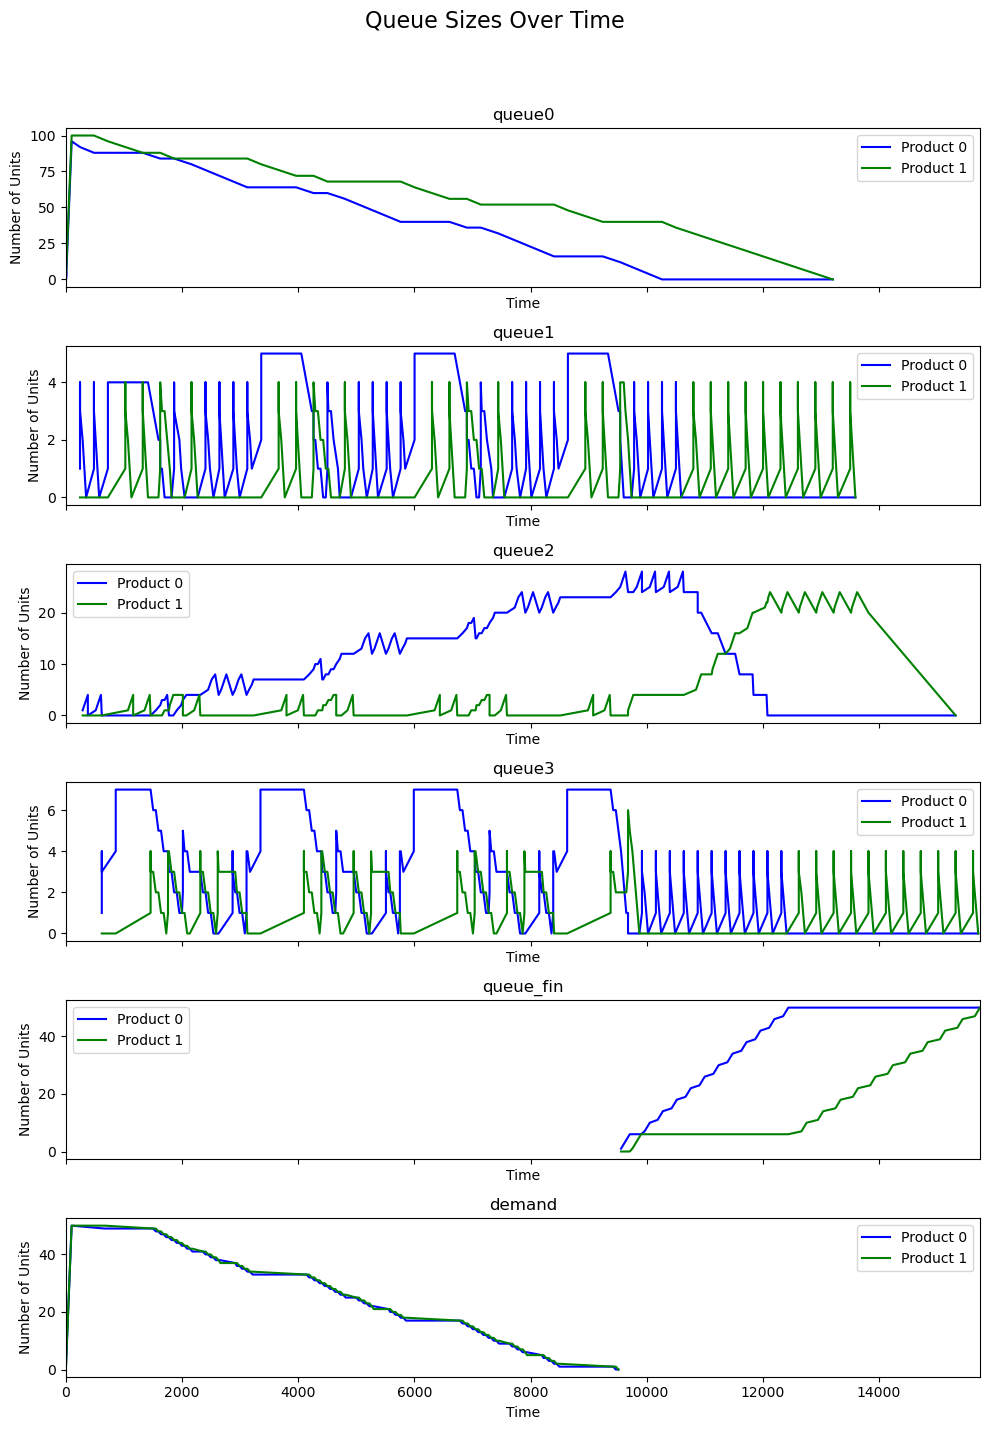

In [6]:
import matplotlib.pyplot as plt

# Plotting queue sizes including 'queue_fin'
fig, axes = plt.subplots(6, 1, figsize=(10, 15), sharex=True)  # Share x-axis across all subplots and increase to 5 subplots
fig.suptitle('Queue Sizes Over Time', fontsize=16)

queue_names = ['queue0', 'queue1', 'queue2', 'queue3', 'queue_fin','demand']
colors = ['blue', 'green']
labels = ['Product 0', 'Product 1']

# Determine the global minimum and maximum time across all queues for consistent x-axis
all_times = [log[1] for queue in queue_names for log in production_line.logs[queue]]
global_min_time = min(all_times)
global_max_time = max(all_times)

for i, ax in enumerate(axes):
    for product_type in range(2):
        times = [log[1] for log in production_line.logs[queue_names[i]]]
        sizes = [log[0][product_type] for log in production_line.logs[queue_names[i]]]
        ax.plot(times, sizes, color=colors[product_type], label=f'Product {product_type}')
    ax.set_title(f'{queue_names[i]}')
    ax.set_xlim([global_min_time, global_max_time])  # Set consistent x-axis range
    ax.set_xlabel('Time')
    ax.set_ylabel('Number of Units')
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Setup for Gantt chart plotting using matplotlib
fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Gantt Chart for Production Line')

# Color coding for products and setups
colors = {0: 'skyblue', 1: 'lightgreen', 'setup': 'grey'}

machines = ['machine0', 'machine1', 'machine2', 'machine3']
machine_names = ['Batch Machine 0', 'Machine 1', 'Batch Machine 2', 'Machine 3']

# Plot each machine's activities
for ax, machine_name, name in zip(axs, machines, machine_names):
    machine = getattr(production_line, machine_name)
    y = 0
    for log in machine.event_log:
        if len(log) == 4:  # BatchProcessingMachine or Machine with setup
            product, current_time, start_time, finish_time = log
            # Calculate setup time and process time
            setup_time = start_time - current_time
            process_time = finish_time - start_time
            # Plot setup time if exists
            if setup_time > 0:
                ax.broken_barh([(current_time, setup_time)], (y, 0.8), facecolors='grey', edgecolor='black', linewidth=0.5)
            # Plot process time
            ax.broken_barh([(start_time, process_time)], (y, 0.8), facecolors=colors[product], edgecolor='black', linewidth=0.5)
        else:  # For single product processing without batch
            product, current_time, finish_time, _ = log
            process_time = finish_time - current_time
            ax.broken_barh([(current_time, process_time)], (y, 0.8), facecolors=colors[product], edgecolor='black', linewidth=0.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_yticks([0])
    ax.set_yticklabels([name])
    ax.grid(True)

# Create legend for product colors
patches = [mpatches.Patch(color=colors[key], label=f'Product {key}' if key != 'setup' else 'Setup Time') for key in colors]
fig.legend(handles=patches, loc='upper right')

plt.xlabel('Time')
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make room for title
plt.show()

In [ ]:
#Next steps
# 1) Introduce a demand forecast into the state space and reward it for meeting future excess demand
# 2) See if it can switch demand patterns quickly 
# 3) Q-learning implementaion to achive the same result
# 4) Write a LP program of this

In [ ]:
queues = {'queue0': [[], []], 'queue1': [[], []], 'queue2': [[], []], 'queue3': [[], []],'queue_fin': [[], []],'demand': [[10,12], [23,45,54]]}
print(len(queues['demand'][0])+len(queues['demand'][1]))
for product_type in range(2):
    print(product_type)